### Automated Stance Adverbial Detector
### Fine-tuning DeBERTa for stance classification in BNC corpus data

#### Khaled Ahmed | MA Corpus Linguistics, Vilnius University

### Labels:

##### E → Epistemic (certainty/doubt): certainly, probably, perhaps
##### A → Attitudinal (evaluation): unfortunately, surprisingly, frankly
##### N → Non-stance (adverb used without stance function)
##### Framework: Biber and Finegan (1988), Biber et al. (1999), and Biber (2006).
##### Data: 8242 manually annotated concordance lines from BNC1994 and BNC2014 Academic Prose and E-language registers.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from pathlib import Path

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
)

warnings.filterwarnings('ignore')

# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path('.')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

/Users/khaled/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: cpu
PyTorch: 2.8.0


## 2. Load & Inspect Data
###### Highlighting evaluative words that might appear after an epistemic expression

In [41]:
import re

LABEL_MAP   = {'E': 0, 'A': 1, 'N': 2}
LABEL_NAMES = ['Epistemic', 'Attitudinal', 'Non-stance']

EVALUATIVE_WORDS = {
    'important', 'significant', 'remarkable', 'surprising', 'unfortunate',
    'critical', 'crucial', 'essential', 'problematic', 'concerning',
    'valuable', 'useful', 'relevant', 'interesting', 'notable',
    'worrying', 'disappointing', 'impressive', 'striking', 'alarming',
    'unacceptable', 'inadequate', 'inappropriate', 'insufficient',
    'fundamental', 'necessary', 'vital', 'urgent', 'serious', 'severe',
    'problem', 'issue', 'challenge', 'failure', 'success', 'achievement',
    'concern', 'risk', 'threat', 'opportunity', 'weakness', 'strength',
    'limitation', 'advantage', 'disadvantage', 'benefit', 'harm', 'damage',
    'fail', 'succeed', 'struggle', 'lack', 'ignore', 'neglect', 'undermine'
}

def clean_text(s):
    if pd.isna(s): return ''
    return re.sub(r'\s+', ' ', str(s).strip())

def build_enriched_text(row):
    adverb_lower = row['adverb'].lower().strip().rstrip('.,')
    right        = row['right_context'].lower()
    right_words  = set(re.findall(r'\b\w+\b', right))
    eval_marker  = '<<EVALUATIVE>>' if right_words & EVALUATIVE_WORDS else ''
    markers      = eval_marker
    return (
        row['left_context'] +
        ' **' + row['adverb'].upper() + '** ' +
        markers + ' ' +
        row['right_context']
    ).strip()

## 3. All subcorpora files 
#### Academic Prose (AP1994 and AP2014) + E-language (EL1994 and EL2014)

In [11]:
ALL_FILES = {
    'Appendix1.AP1994.xlsx': {
        'register': 'AP1994',
        'sheets': ['500_con_clearly', '500_con_probably', '500_con_Indeed',
                   '500_con_unfortunately', '500_con_perhaps']
    },
    'Appendix2.AP2014.xlsx': {
        'register': 'AP2014',
        'sheets': ['500_con_indeed', '500_con_perhaps', '500_con_clearly',
                   '500_con_actually', '500_con_probably']
    },
    'Appendix3.EL1994.xlsx': {
        'register': 'EL1994',
        'sheets': ['BNC1994_elan_ACTUALLY', 'BNC1994_elan_maybe',
                   'BNC1994_elan_perhaps', 'BNC1994_elan_probably',
                   'BNC1994_elan_really']
    },
    'Appendix4.EL2014.xlsx': {
        'register': 'EL2014',
        'sheets': ['500_conc_actually', '500_conc_definitely', '500_conc_maybe',
                   '500_conc_probably', '500_conc_really']
    }
}
def load_sheet_generic(xl, sheet_name, register):
    raw = xl.parse(sheet_name, header=None)
    df = raw.iloc[:, [0, 1, 2, -1]].copy()
    df.columns = ['left_context', 'adverb', 'right_context', 'label']
    for col in ['left_context', 'adverb', 'right_context']:
        df[col] = df[col].apply(clean_text)
    df['label'] = df['label'].astype(str).str.strip().str.upper()
    df['register'] = register
    df['adverb_sheet'] = sheet_name
    return df[df['label'].isin(LABEL_MAP)]

all_dfs = []
for filename, info in ALL_FILES.items():
    xl = pd.ExcelFile(filename)
    for sheet in info['sheets']:
        try:
            sheet_df = load_sheet_generic(xl, sheet, info['register'])
            all_dfs.append(sheet_df)
            print(f"✓ {filename} | {sheet}: {len(sheet_df)} rows")
        except Exception as e:
            print(f"✗ {filename} | {sheet}: {e}")

df = pd.concat(all_dfs, ignore_index=True)
df['text']       = df.apply(build_enriched_text, axis=1)
df['label_id']   = df['label'].map(LABEL_MAP)
df['label_name'] = df['label_id'].map(dict(enumerate(LABEL_NAMES)))

print(f'\nTotal instances: {len(df)}')
print('\nBy register:')
print(df['register'].value_counts())
print('\nLabel distribution:')
print(df['label_name'].value_counts())

✓ Appendix1.AP1994.xlsx | 500_con_clearly: 500 rows
✓ Appendix1.AP1994.xlsx | 500_con_probably: 500 rows
✓ Appendix1.AP1994.xlsx | 500_con_Indeed: 500 rows
✓ Appendix1.AP1994.xlsx | 500_con_unfortunately: 500 rows
✓ Appendix1.AP1994.xlsx | 500_con_perhaps: 500 rows
✓ Appendix2.AP2014.xlsx | 500_con_indeed: 500 rows
✓ Appendix2.AP2014.xlsx | 500_con_perhaps: 500 rows
✓ Appendix2.AP2014.xlsx | 500_con_clearly: 500 rows
✓ Appendix2.AP2014.xlsx | 500_con_actually: 500 rows
✓ Appendix2.AP2014.xlsx | 500_con_probably: 500 rows
✓ Appendix3.EL1994.xlsx | BNC1994_elan_ACTUALLY: 87 rows
✓ Appendix3.EL1994.xlsx | BNC1994_elan_maybe: 170 rows
✓ Appendix3.EL1994.xlsx | BNC1994_elan_perhaps: 77 rows
✓ Appendix3.EL1994.xlsx | BNC1994_elan_probably: 163 rows
✓ Appendix3.EL1994.xlsx | BNC1994_elan_really: 245 rows
✓ Appendix4.EL2014.xlsx | 500_conc_actually: 500 rows
✓ Appendix4.EL2014.xlsx | 500_conc_definitely: 500 rows
✓ Appendix4.EL2014.xlsx | 500_conc_maybe: 500 rows
✓ Appendix4.EL2014.xlsx | 500_

## 4. Class Distribution
#### Showing number of instances of each class (Gold standard refers to the manually annotated corpora).

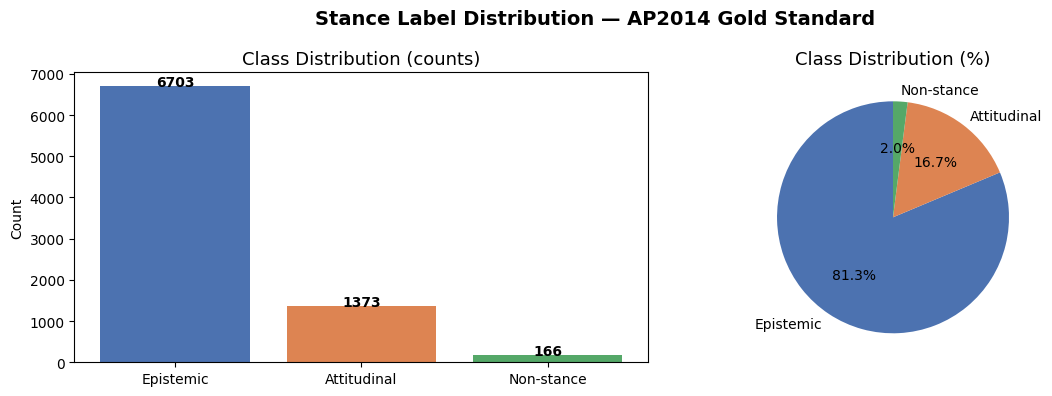

label_name
Epistemic      6703
Attitudinal    1373
Non-stance      166
Name: count, dtype: int64


In [42]:
# class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label_name'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution (counts)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('Stance Label Distribution — AP2014 Gold Standard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts)

## 5. Most Frequent Adverbs Per Class

In [44]:
for label in ['Epistemic', 'Attitudinal']:
    top = (
        df[df['label_name'] == label]['adverb']
        .str.lower()
        .str.strip('.,;:!?')  # strip punctuation
        .value_counts()
        .head(10)
    )
    print(f'\n{label}:')
    print(top.to_string())


Epistemic:
adverb
probably      1510
actually       988
perhaps        937
clearly        901
indeed         900
maybe          615
really         418
definitely     373
probably)        6
perhaps '        5

Attitudinal:
adverb
unfortunately    496
really           306
probably         124
definitely       121
perhaps          109
indeed            88
actually          74
clearly           24
maybe             24
indeed)            1


## 6. Baseline: Rule-Based Lexicon Classifier
Simple lookup table, establishing a performance floor to compare against deberta. This classification predicts the stance based on the linguistic device used, based on Biber and Finegan (1988, Biber et al. 1999, and Biber 2006).

In [46]:
# Biber et al. (1999) stance adverbial lexicons
EPISTEMIC_LEXICON = {
    'certainly', 'clearly', 'obviously', 'undoubtedly', 'definitely',
    'presumably', 'probably', 'perhaps', 'possibly', 'conceivably',
    'apparently', 'evidently', 'seemingly', 'allegedly', 'supposedly',
    'indeed', 'actually', 'really', 'surely', 'necessarily'
}

ATTITUDINAL_LEXICON = {
    'unfortunately', 'fortunately', 'luckily', 'unluckily',
    'surprisingly', 'astonishingly', 'remarkably', 'interestingly',
    'frankly', 'honestly', 'admittedly', 'importantly',
    'conveniently', 'absurdly', 'curiously', 'predictably'
}

def lexicon_predict(adverb):
    a = adverb.lower().strip()
    if a in EPISTEMIC_LEXICON:   return 0  # Epistemic
    if a in ATTITUDINAL_LEXICON: return 1  # Attitudinal
    return 2  # Non-stance (default)

df['lexicon_pred'] = df['adverb'].apply(lexicon_predict)

lex_acc = accuracy_score(df['label_id'], df['lexicon_pred'])
lex_f1  = f1_score(df['label_id'], df['lexicon_pred'], average='macro')
lex_k   = cohen_kappa_score(df['label_id'], df['lexicon_pred'])

print('=== Lexicon Baseline ===')
print(f'Accuracy:     {lex_acc:.3f}')
print(f'Macro F1:     {lex_f1:.3f}')
print(f"Cohen's κ:    {lex_k:.3f}")
print()
print(classification_report(df['label_id'], df['lexicon_pred'],
                             target_names=LABEL_NAMES))

=== Lexicon Baseline ===
Accuracy:     0.669
Macro F1:     0.384
Cohen's κ:    0.139

              precision    recall  f1-score   support

   Epistemic       0.85      0.78      0.81      6703
 Attitudinal       1.00      0.17      0.29      1373
  Non-stance       0.03      0.29      0.05       166

    accuracy                           0.67      8242
   macro avg       0.63      0.41      0.38      8242
weighted avg       0.86      0.67      0.71      8242



## 7. Train / Test Split
#### The training included 3 elements: Manual analysis (Gold standard), Baseline lexicon markers, and an additional element based on a research finding: evaluative content words that occur after the epistemic marker transforms the propositional content into attitudinal. 

In [15]:
EVALUATIVE_WORDS = {
    'important', 'significant', 'remarkable', 'surprising', 'unfortunate',
    'critical', 'crucial', 'essential', 'problematic', 'concerning',
    'valuable', 'useful', 'relevant', 'interesting', 'notable',
    'worrying', 'disappointing', 'impressive', 'striking', 'alarming',
    'unacceptable', 'inadequate', 'inappropriate', 'insufficient',
    'fundamental', 'necessary', 'vital', 'urgent', 'serious', 'severe',
    'problem', 'issue', 'challenge', 'failure', 'success', 'achievement',
    'concern', 'risk', 'threat', 'opportunity', 'weakness', 'strength',
    'limitation', 'advantage', 'disadvantage', 'benefit', 'harm', 'damage',
    'fail', 'succeed', 'struggle', 'lack', 'ignore', 'neglect', 'undermine',
    'improve', 'worsen', 'enhance', 'damage', 'support', 'oppose'
}

EPISTEMIC_LEXICON = {
    'certainly', 'clearly', 'obviously', 'undoubtedly', 'definitely',
    'presumably', 'probably', 'perhaps', 'possibly', 'conceivably',
    'apparently', 'evidently', 'seemingly', 'allegedly', 'supposedly',
    'indeed', 'actually', 'really', 'surely', 'necessarily'
}

ATTITUDINAL_LEXICON = {
    'unfortunately', 'fortunately', 'luckily', 'unluckily',
    'surprisingly', 'astonishingly', 'remarkably', 'interestingly',
    'frankly', 'honestly', 'admittedly', 'importantly',
    'conveniently', 'absurdly', 'curiously', 'predictably'
}

def build_enriched_text(row):
    adverb_lower = row['adverb'].lower().strip().rstrip('.,')
    right        = row['right_context'].lower()
    right_words  = set(re.findall(r'\b\w+\b', right))

    # evaluative marker
    eval_marker = '<<EVALUATIVE>>' if right_words & EVALUATIVE_WORDS else ''

    # lexicon marker
    if adverb_lower in ATTITUDINAL_LEXICON:
        lex_marker = '<<LEXICON:ATTITUDINAL>>'
    elif adverb_lower in EPISTEMIC_LEXICON:
        # override to attitudinal if evaluative context found
        if right_words & EVALUATIVE_WORDS:
            lex_marker = '<<LEXICON:ATTITUDINAL>>'
        else:
            lex_marker = '<<LEXICON:EPISTEMIC>>'
    else:
        lex_marker = '<<LEXICON:NONSTANCE>>'

    markers = ' '.join(filter(None, [eval_marker, lex_marker]))

    return (
        row['left_context'] +
        ' **' + row['adverb'].upper() + '** ' +
        markers + ' ' +
        row['right_context']
    ).strip()

df['text'] = df.apply(build_enriched_text, axis=1)

# inspect distribution
print('Marker distribution:')
for marker in ['<<EVALUATIVE>>', '<<LEXICON:EPISTEMIC>>', '<<LEXICON:ATTITUDINAL>>', '<<LEXICON:NONSTANCE>>']:
    count = df['text'].str.contains(marker).sum()
    print(f'  {marker}: {count}')

print('\nSample enriched texts:')
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"  [{row['label_name']}] {row['text'][:100]}...")
    print()

Marker distribution:
  <<EVALUATIVE>>: 474
  <<LEXICON:EPISTEMIC>>: 6549
  <<LEXICON:ATTITUDINAL>>: 928
  <<LEXICON:NONSTANCE>>: 765

Sample enriched texts:
  [Attitudinal] the manufacturer would like a feasible solution maximising them all. **UNFORTUNATELY** <<LEXICON:ATT...

  [Epistemic] feel that another reviewer was way off base, it is **PROBABLY** <<LEXICON:EPISTEMIC>> best to discus...

  [Attitudinal] Yes, we heard of it even on the same day. **UNFORTUNATELY,** <<LEXICON:ATTITUDINAL>> the gents had b...



In [16]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df['label_id']   # preserve class proportions in both splits
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# further split train → train + validation (80/10/10)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.125,  # 0.125 of 80% = 10% of total
    random_state=SEED,
    stratify=train_df['label_id']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# save processed data
df.to_csv('data/processed/stance_all.csv', index=False)
train_df.to_csv('data/processed/stance_train.csv', index=False)
val_df.to_csv('data/processed/stance_val.csv', index=False)
test_df.to_csv('data/processed/stance_test.csv', index=False)
print('Splits saved.')

Train: 5768 | Val: 825 | Test: 1649
Splits saved.


In [17]:
import sys
!{sys.executable} -m pip install --upgrade transformers

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [37]:
from torch.nn import CrossEntropyLoss
MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LEN    = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print(f'Loaded tokenizer: {MODEL_NAME}')

Loaded tokenizer: microsoft/deberta-v3-base


In [19]:
class StanceDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.texts  = dataframe['text'].tolist()
        self.labels = dataframe['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = StanceDataset(train_df, tokenizer, MAX_LEN)
val_dataset   = StanceDataset(val_df,   tokenizer, MAX_LEN)
test_dataset  = StanceDataset(test_df,  tokenizer, MAX_LEN)

print(f'Train dataset: {len(train_dataset)} examples')
print(f'Val dataset:   {len(val_dataset)} examples')
print(f'Test dataset:  {len(test_dataset)} examples')

# inspect one tokenized example
sample = train_dataset[0]
print(f'\nSample token count: {sample["attention_mask"].sum().item()}')
print(f'Label: {LABEL_NAMES[sample["labels"].item()]}')

Train dataset: 5768 examples
Val dataset:   825 examples
Test dataset:  1649 examples

Sample token count: 44
Label: Epistemic


## 8. Calculating Evaluation Metrics



In [47]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'kappa':    cohen_kappa_score(labels, preds)
    }

## 9. Training with 7 epochs.

In [21]:
# more aggressive weights + 7 epochs + lower learning rate
label_counts = torch.tensor([2245, 174, 81], dtype=torch.float)
class_weights = (label_counts.max() / label_counts)  # inverse frequency
print(f'Class weights: {class_weights}')
# → Epistemic ~1.0, Attitudinal ~12.9, Non-stance ~27.7

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: 'Epistemic', 1: 'Attitudinal', 2: 'Non-stance'},
    label2id={'Epistemic': 0, 'Attitudinal': 1, 'Non-stance': 2}
)

training_args = TrainingArguments(
    output_dir='models/DeBERTa-stance-v2',
    num_train_epochs=7,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to='none',
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print('Starting fine-tuning v2 (7 epochs, aggressive weights)...')
trainer.train()

Class weights: tensor([ 1.0000, 12.9023, 27.7160])


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting fine-tuning v2 (7 epochs, aggressive weights)...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Kappa
1,0.699300,0.693298,0.750303,0.457864,0.386692
2,0.471300,0.695007,0.850909,0.527833,0.563075
3,0.501800,0.776109,0.884848,0.614200,0.630345
4,0.467200,0.999309,0.870303,0.608855,0.590888
5,0.296700,1.028707,0.872727,0.658316,0.609829
6,0.320900,1.148185,0.870303,0.633610,0.602708
7,0.288100,1.131439,0.873939,0.646608,0.609769


TrainOutput(global_step=2527, training_loss=0.4714325371588649, metrics={'train_runtime': 6706.3329, 'train_samples_per_second': 6.021, 'train_steps_per_second': 0.377, 'total_flos': 5311828936028160.0, 'train_loss': 0.4714325371588649, 'epoch': 7.0})

## 10. Parameters

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: 'Epistemic', 1: 'Attitudinal', 2: 'Non-stance'},
    label2id={'Epistemic': 0, 'Attitudinal': 1, 'Non-stance': 2}
)
print(f'Model loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}')

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded. Parameters: 184,424,451


In [48]:
# run inference on test set
predictions = trainer.predict(test_dataset)
preds    = np.argmax(predictions.predictions, axis=-1)
gold     = predictions.label_ids

acc   = accuracy_score(gold, preds)
mac_f1 = f1_score(gold, preds, average='macro')
kappa  = cohen_kappa_score(gold, preds)

print('=' * 50)
print('DeBERTa FINE-TUNED — TEST SET RESULTS')
print('=' * 50)
print(f'Accuracy:     {acc:.3f}')
print(f'Macro F1:     {mac_f1:.3f}')
print(f"Cohen's κ:    {kappa:.3f}")
print()
print(classification_report(gold, preds, target_names=LABEL_NAMES))

print('\n=== COMPARISON: Lexicon Baseline vs DeBERTa ===')
print(f'{"":<15} {"Accuracy":>10} {"Macro F1":>10} {"Cohen κ":>10}')
print(f'{"Lexicon":<15} {lex_acc:>10.3f} {lex_f1:>10.3f} {lex_k:>10.3f}')
print(f'{"DeBERTa":<15} {acc:>10.3f} {mac_f1:>10.3f} {kappa:>10.3f}')

DeBERTa FINE-TUNED — TEST SET RESULTS
Accuracy:     0.890
Macro F1:     0.667
Cohen's κ:    0.645

              precision    recall  f1-score   support

   Epistemic       0.93      0.94      0.93      1341
 Attitudinal       0.79      0.73      0.76       275
  Non-stance       0.27      0.36      0.31        33

    accuracy                           0.89      1649
   macro avg       0.66      0.68      0.67      1649
weighted avg       0.89      0.89      0.89      1649


=== COMPARISON: Lexicon Baseline vs DeBERTa ===
                  Accuracy   Macro F1    Cohen κ
Lexicon              0.669      0.384      0.139
DeBERTa              0.890      0.667      0.645


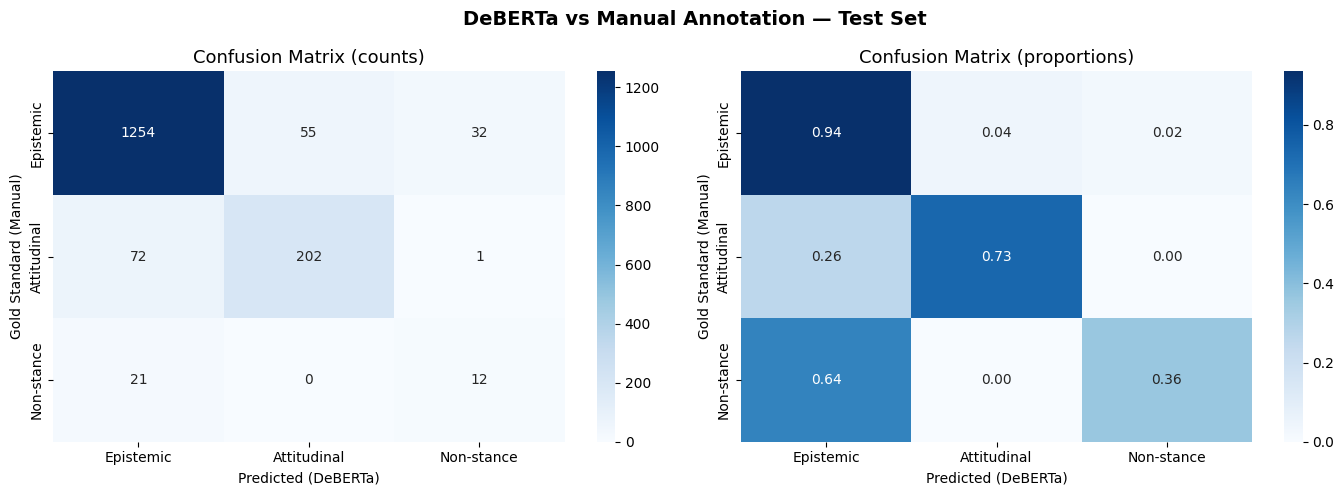

In [49]:
# confusion matrix
cm = confusion_matrix(gold, preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)
axes[0].set_ylabel('Gold Standard (Manual)')
axes[0].set_xlabel('Predicted (DeBERTa)')

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (proportions)', fontsize=13)
axes[1].set_ylabel('Gold Standard (Manual)')
axes[1].set_xlabel('Predicted (DeBERTa)')

plt.suptitle('DeBERTa vs Manual Annotation — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

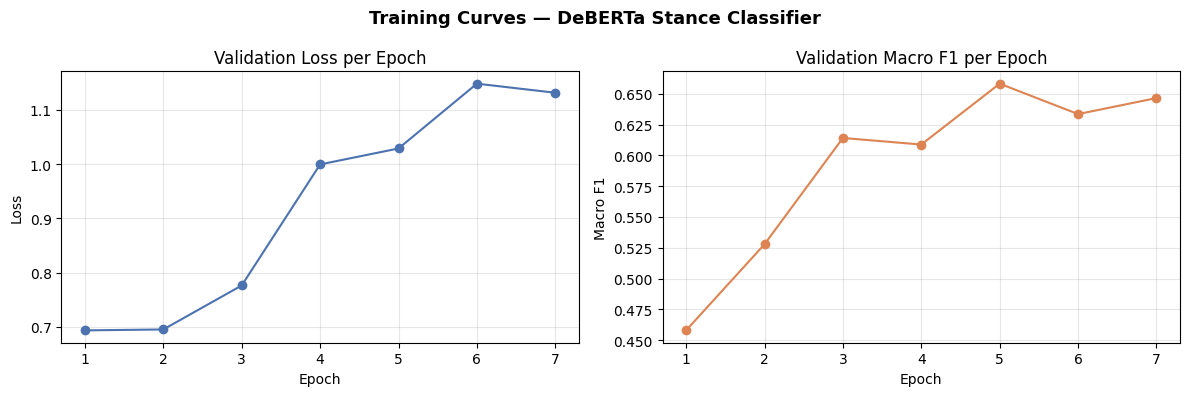

In [50]:
# training curve — loss per epoch
log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

if eval_logs:
    epochs    = [x['epoch'] for x in eval_logs]
    eval_loss = [x['eval_loss'] for x in eval_logs]
    eval_f1   = [x.get('eval_macro_f1', 0) for x in eval_logs]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, eval_loss, 'o-', color='#4C72B0')
    axes[0].set_title('Validation Loss per Epoch')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, eval_f1, 'o-', color='#DD8452')
    axes[1].set_title('Validation Macro F1 per Epoch')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
    axes[1].grid(alpha=0.3)

    plt.suptitle('Training Curves — DeBERTa Stance Classifier', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/figures/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Error Analysis

In [51]:
test_df['predicted']      = preds
test_df['predicted_name'] = [LABEL_NAMES[p] for p in preds]
test_df['correct']        = (test_df['label_id'] == test_df['predicted'])

errors = test_df[~test_df['correct']].copy()
print(f'Total errors: {len(errors)} / {len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)')

print('\nError patterns (gold → predicted):')
error_counts = (
    errors.groupby(['label_name', 'predicted_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print(error_counts.to_string(index=False))

Total errors: 181 / 1649 (11.0%)

Error patterns (gold → predicted):
 label_name predicted_name  count
Attitudinal      Epistemic     72
  Epistemic    Attitudinal     55
  Epistemic     Non-stance     32
 Non-stance      Epistemic     21
Attitudinal     Non-stance      1


In [52]:
# most error-prone adverbs
print('Adverbs with most errors:')
print(
    errors.groupby('adverb')['correct']
    .count()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)

print('\nError rate by adverb (min 3 test occurrences):')
adverb_stats = test_df.groupby('adverb').agg(
    total=('correct', 'count'),
    errors=('correct', lambda x: (~x).sum())
).query('total >= 3')
adverb_stats['error_rate'] = adverb_stats['errors'] / adverb_stats['total']
print(adverb_stats.sort_values('error_rate', ascending=False).head(15).to_string())

Adverbs with most errors:
adverb
perhaps       23
actually      23
clearly       20
probably      19
really        18
indeed        18
definitely    11
Perhaps        7
maybe          6
Definitely     5
Probably       4
Indeed,        3
indeed,        1
clearly:       1
Actually       1

Error rate by adverb (min 3 test occurrences):
            total  errors  error_rate
adverb                               
really,         3       1    0.333333
actually.       3       1    0.333333
REALLY          4       1    0.250000
Definitely     21       5    0.238095
indeed         78      18    0.230769
Perhaps        34       7    0.205882
Probably       21       4    0.190476
Actually        6       1    0.166667
really        111      18    0.162162
perhaps       147      23    0.156463
actually,       7       1    0.142857
definitely     81      11    0.135802
clearly       171      20    0.116959
actually      227      23    0.101322
maybe          83       6    0.072289


In [29]:
# show sample errors — qualitative inspection
print('=== Sample Errors: Epistemic → Attitudinal ===')
mask = (errors['label_name'] == 'Epistemic') & (errors['predicted_name'] == 'Attitudinal')
for _, row in errors[mask].head(3).iterrows():
    print(f"  Adverb: {row['adverb']}")
    print(f"  Text:   {row['text'][:120]}...")
    print()

print('=== Sample Errors: Non-stance → Epistemic ===')
mask = (errors['label_name'] == 'Non-stance') & (errors['predicted_name'] == 'Epistemic')
for _, row in errors[mask].head(3).iterrows():
    print(f"  Adverb: {row['adverb']}")
    print(f"  Text:   {row['text'][:120]}...")
    print()

=== Sample Errors: Epistemic → Attitudinal ===
  Adverb: indeed
  Text:   else's business, it is argued. It is tempting and **INDEED** <<LEXICON:EPISTEMIC>> justifiable for the purposes of strai...

  Adverb: perhaps
  Text:   is common to both phenomenology and Goethean science. It is **PERHAPS** <<LEXICON:EPISTEMIC>> most succinctly expressed ...

  Adverb: Probably
  Text:   hearing aids, lots of disruption /cutting out/ intermittent ringing sound **PROBABLY** <<LEXICON:EPISTEMIC>> the best I'...

=== Sample Errors: Non-stance → Epistemic ===
  Adverb: actually
  Text:   relationship they struggled to identify anyone else that they could **ACTUALLY** <<LEXICON:EPISTEMIC>> confide in.I mean...

  Adverb: maybe)
  Text:   Well, I upgraded from the 3B, thinking that maybe (just **MAYBE)** <<LEXICON:NONSTANCE>> this could scrape through as a ...

  Adverb: actually
  Text:   reciprocity, at least one friendship among unequals in Timon is **ACTUALLY** <<LEXICON:EPISTEMIC>> real; that is 

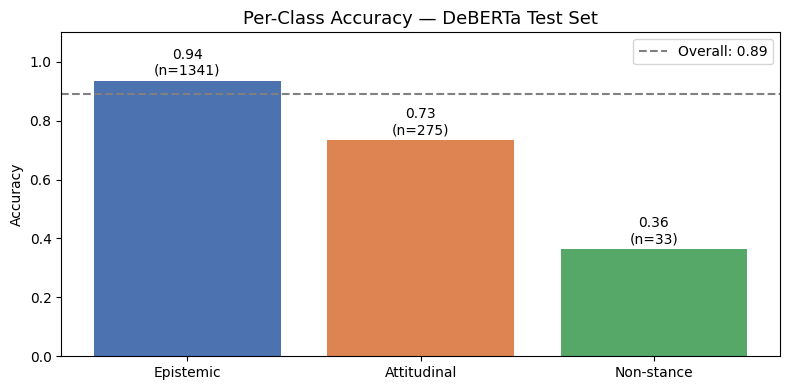

In [38]:
# per-class accuracy bar chart
per_class_acc = []
for i, name in enumerate(LABEL_NAMES):
    mask = gold == i
    if mask.sum() > 0:
        acc_i = (preds[mask] == gold[mask]).mean()
        per_class_acc.append({'Class': name, 'Accuracy': acc_i, 'Count': mask.sum()})

acc_df = pd.DataFrame(per_class_acc)
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(acc_df['Class'], acc_df['Accuracy'], color=colors)
ax.axhline(acc, linestyle='--', color='gray', label=f'Overall: {acc:.2f}')
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Accuracy — DeBERTa Test Set', fontsize=13)
ax.set_ylabel('Accuracy')
ax.legend()
for bar, row in zip(bars, acc_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{row.Accuracy:.2f}\n(n={row.Count})', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('results/figures/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary Table 

In [55]:
from sklearn.metrics import precision_score, recall_score

summary = pd.DataFrame({
    'Model': ['Lexicon Baseline', 'deBERTa (fine-tuned)'],
    'Accuracy': [lex_acc, acc],
    'Macro F1': [lex_f1, mac_f1],
    "Cohen's κ": [lex_k, kappa],
})
summary['Accuracy'] = summary['Accuracy'].map('{:.3f}'.format)
summary['Macro F1'] = summary['Macro F1'].map('{:.3f}'.format)
summary["Cohen's κ"] = summary["Cohen's κ"].map('{:.3f}'.format)

print('=== RESULTS SUMMARY ===')
print(summary.to_string(index=False))

summary.to_csv('results/results_summary.csv', index=False)

# save error analysis
errors[['adverb', 'label_name', 'predicted_name', 'text']].to_csv(
    'results/error_analysis.csv', index=False
)

print('\nAll results saved to results/')

=== RESULTS SUMMARY ===
               Model Accuracy Macro F1 Cohen's κ
    Lexicon Baseline    0.669    0.384     0.139
deBERTa (fine-tuned)    0.890    0.667     0.645

All results saved to results/


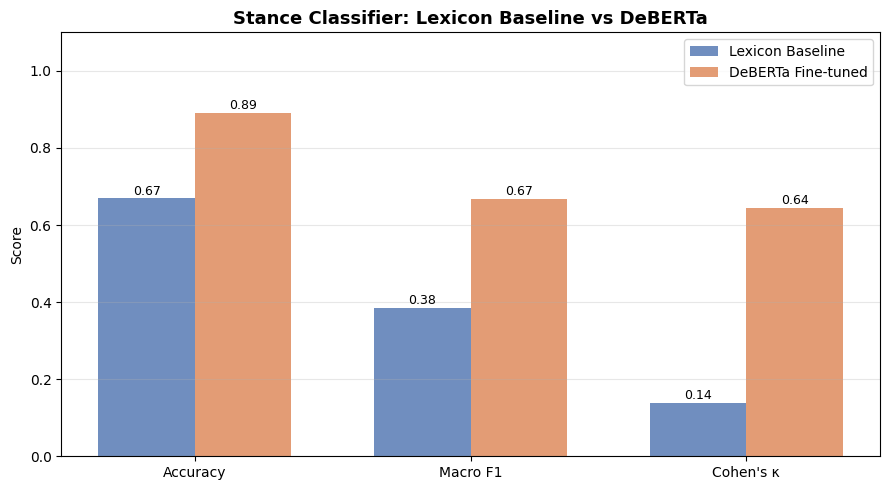

In [56]:
# comparison bar chart: baseline vs DeBERTa
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', "Cohen's κ"],
    'Lexicon': [lex_acc, lex_f1, lex_k],
    'DeBERTa':   [acc, mac_f1, kappa]
})

x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, metrics_df['Lexicon'], w, label='Lexicon Baseline', color='#4C72B0', alpha=0.8)
b2 = ax.bar(x + w/2, metrics_df['DeBERTa'],   w, label='DeBERTa Fine-tuned', color='#DD8452', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Metric'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Stance Classifier: Lexicon Baseline vs DeBERTa', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/figures/baseline_vs_DeBERTa.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Save Model

In [57]:
model.save_pretrained('models/deberta-stance/best')
tokenizer.save_pretrained('models/deberta-stance/best')
print('Model saved to models/deberta-stance/best')
print('\nTo reload:')
print('  from transformers import AutoModelForSequenceClassification, AutoTokenizer')
print('  model = AutoModelForSequenceClassification.from_pretrained("models/deberta-stance/best")')
print('  tokenizer = AutoTokenizer.from_pretrained("models/deberta-stance/best")')

Model saved to models/deberta-stance/best

To reload:
  from transformers import AutoModelForSequenceClassification, AutoTokenizer
  model = AutoModelForSequenceClassification.from_pretrained("models/deberta-stance/best")
  tokenizer = AutoTokenizer.from_pretrained("models/deberta-stance/best")


## 14. Errors saved to an EXCEL file for Manual Inspection

In [63]:
# export clean test set for manual inspection
inspection = test_df.copy()

# build full concordance line: left + adverb + right
inspection['concordance'] = (
    inspection['left_context'] + ' ' + 
    inspection['adverb'] + ' ' + 
    inspection['right_context']
).str.strip()

# keep only what's needed
inspection = inspection[['concordance', 'label_name', 'predicted_name', 'correct']].copy()
inspection.columns = ['Concordance Line', 'Gold Standard', 'Predicted', 'Correct']

# sort: errors first
inspection = inspection.sort_values('Correct', ascending=True).reset_index(drop=True)

# save all rows
inspection.to_excel('results/manual_inspection.xlsx', index=False)

# save errors only
errors_only = inspection[inspection['Correct'] == False]
errors_only.to_excel('results/errors_only.xlsx', index=False)

total   = len(inspection)
errors  = len(errors_only)
correct = total - errors

print(f'Total:   {total}')
print(f'Errors:  {errors} ({errors/total*100:.1f}%) → saved to results/errors_only.xlsx')
print(f'Correct: {correct} ({correct/total*100:.1f}%) → saved to results/manual_inspection.xlsx')

Total:   1649
Errors:  181 (11.0%) → saved to results/errors_only.xlsx
Correct: 1468 (89.0%) → saved to results/manual_inspection.xlsx


## 15. Save Results

In [61]:
import json
from datetime import date

results = {
    "date": str(date.today()),
    "dataset": {
        "total_instances": 8242,
        "train": 5768,
        "val": 825,
        "test": 1649,
        "registers": ["AP1994", "AP2014", "EL1994", "EL2014"],
        "adverbs": ["indeed", "perhaps", "clearly", "actually", "probably",
                    "unfortunately", "maybe", "really", "definitely"]
    },
    "model": "microsoft/deberta-v3-base",
    "features": "evaluative_marker + lexicon_marker",
    "best_epoch": 5,
    "training": {
        "epochs": 7,
        "learning_rate": "1e-5",
        "batch_size": 16,
        "class_weights": "inverse frequency"
    },
    "results": {
        "lexicon_baseline": {
            "accuracy": 0.669,
            "macro_f1": 0.384,
            "cohen_kappa": 0.139
        },
        "deberta_finetuned": {
            "accuracy": 0.890,
            "macro_f1": 0.667,
            "cohen_kappa": 0.645
        },
        "per_class": {
            "Epistemic":   {"precision": 0.93, "recall": 0.94, "f1": 0.93, "support": 1341},
            "Attitudinal": {"precision": 0.79, "recall": 0.73, "f1": 0.76, "support": 275},
            "Non-stance":  {"precision": 0.27, "recall": 0.36, "f1": 0.31, "support": 33}
        }
    },
    "notes": "Best model saved at models/deberta-stance/best. To be applied to MERLIN (Italian L2) and ZAEBUC (Arabic L2) learner corpora."
}

with open('results/BNC_pilot_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Saved → results/BNC_pilot_results.json')

Saved → results/BNC_pilot_results.json
